# 🇻🇳 Fine-tune BARTpho-word cho Tóm Tắt Văn Bản Tiếng Việt

**Mô hình:** `vinai/bartpho-word`  
**Nhiệm vụ:** Abstractive Summarization  
**Yêu cầu:** GPU (T4 hoặc tốt hơn trên Colab)

> **Khác biệt vs ViT5:**  
> - BARTpho dùng kiến trúc BART (encoder-decoder) với dữ liệu tiếng Việt  
> - Không cần prefix như T5  
> - `as_target_tokenizer()` không áp dụng — encode bình thường  
> - BOS/EOS token xử lý khác T5  

---
### Nội dung notebook:
1. Cài đặt thư viện
2. Mount Google Drive & Load dữ liệu
3. EDA & Kiểm tra số liệu
4. Tokenization & Dataset (BARTpho-specific)
5. Fine-tuning BARTpho-word
6. Đánh giá toàn diện
7. So sánh với ViT5 (nếu có)
8. Inference & Demo
9. Lưu model

## 1. Cài đặt thư viện

In [ ]:
# Fix dependency versions for Google Colab (Python 3.12)
# Chạy cell này đầu tiên. Sau khi chạy xong, chọn Runtime > Restart runtime, rồi chạy các cell tiếp theo.
# Mục tiêu: tránh lỗi kiểu `cannot import name clear_device_cache from accelerate.utils.memory`.
!pip uninstall -y -q peft transformers accelerate datasets evaluate
!pip install -q -U --no-warn-conflicts \
    "transformers==4.41.2" \
    "datasets==2.19.2" \
    "accelerate==0.30.1" \
    "evaluate==0.4.2" \
    "sentencepiece==0.2.0" \
    "rouge-score==0.1.2" \
    "bert-score==0.3.13" \
    "sacrebleu==2.4.0" \
    "nltk" \
    "underthesea" \
    "fastBPE"

# BARTpho-word tokenizer thường cần fairseq. Trên Colab Python 3.12, fairseq đôi khi cài khó hơn,
# nên tách riêng để nếu lỗi thì dễ nhận biết đúng nguyên nhân.
!pip install -q --no-warn-conflicts "fairseq==0.12.2"

import importlib.metadata as md
for pkg in ["transformers", "datasets", "accelerate", "evaluate", "sentencepiece", "rouge-score", "bert-score", "sacrebleu"]:
    try:
        print(pkg, md.version(pkg))
    except md.PackageNotFoundError:
        print(pkg, "NOT INSTALLED")

print("\n✅ Đã cài xong dependency. BẮT BUỘC chọn Runtime > Restart runtime trên Colab, sau đó chạy lại từ cell import bên dưới.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0

In [ ]:
import os, re, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
import evaluate
import transformers, accelerate

print('transformers:', transformers.__version__)
print('accelerate  :', accelerate.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


transformers: 4.41.2
accelerate  : 0.30.1
✅ Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


## 2. Mount Google Drive & Load dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


In [ ]:
DATA_DIR   = '/content/drive/MyDrive/NLP_FINAL/DATA'
OUTPUT_DIR = '/content/drive/MyDrive/NLP_FINAL/BARTPHO_OUTPUT'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df = pd.read_csv(f'{DATA_DIR}/train_for_model.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val_for_model.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test_for_model.csv')

for df, name in [(train_df,'train'),(val_df,'val'),(test_df,'test')]:
    df.dropna(subset=['original_text','summary'], inplace=True)
    df['original_text'] = df['original_text'].astype(str).str.strip()
    df['summary']       = df['summary'].astype(str).str.strip()
    df.reset_index(drop=True, inplace=True)
    print(f'✅ {name}: {len(df)} mẫu')

✅ train: 1244 mẫu
✅ val: 156 mẫu
✅ test: 156 mẫu


## 3. EDA & Kiểm tra số liệu

In [ ]:
def word_count(text):
    return len(str(text).split())

# ============================================================
# HÀM KIỂM TRA ĐỘ CHÍNH XÁC SỐ LIỆU
# Number Accuracy:
# - Chỉ xét các số xuất hiện trong summary/prediction.
# - Nếu số trong summary có trong original_text => đúng.
# - Nếu summary thiếu số từ original_text => KHÔNG phạt.
# - Chỉ phạt khi summary sinh số không có trong original_text.
# ============================================================

def extract_numbers(text):
    """
    Trích xuất số liệu từ văn bản:
    - Số nguyên: 2024, 1000
    - Số thập phân: 10.5, 10,5
    - Phần trăm: 20%
    - Ngày tháng: 12/4, 12/4/2024
    """
    text = str(text)
    pattern = r"""
        \d{1,2}/\d{1,2}(?:/\d{2,4})?   # ngày dạng 12/4 hoặc 12/4/2024
        |
        \d+(?:[.,]\d+)*%?               # số, số thập phân, phần trăm
    """
    nums = re.findall(pattern, text, flags=re.VERBOSE)
    nums = [n.strip() for n in nums if n.strip()]
    return set(nums)


def number_accuracy_rate(src, tgt):
    """
    Đo độ chính xác số liệu theo tiêu chí:
    - src: original_text
    - tgt: summary/prediction

    Nếu tất cả số trong summary đều xuất hiện trong original_text:
        accuracy = 1.0

    Nếu summary sinh ra số không có trong original_text:
        accuracy < 1.0

    Thiếu số trong original_text không bị phạt.
    """
    src_nums = extract_numbers(src)
    tgt_nums = extract_numbers(tgt)

    if len(tgt_nums) == 0:
        return 1.0, set(), set()

    correct_nums = tgt_nums & src_nums
    hallucinated = tgt_nums - src_nums
    missing = src_nums - tgt_nums  # chỉ lưu để tham khảo, không dùng để tính điểm

    accuracy = len(correct_nums) / len(tgt_nums)
    return accuracy, missing, hallucinated


# Tính stats cho từng tập
for df, name in [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]:
    df['src_wc'] = df['original_text'].apply(word_count)
    df['tgt_wc'] = df['summary'].apply(word_count)
    df['ratio']  = df['tgt_wc'] / df['src_wc']
    df['num_accuracy'] = df.apply(
        lambda r: number_accuracy_rate(r['original_text'], r['summary'])[0], axis=1
    )
    compliant = df['ratio'].between(0.20, 0.25).mean()
    print(f'\n=== {name} ({len(df)} mẫu) ===')
    print(f'  src_wc  : mean={df.src_wc.mean():.0f}, max={df.src_wc.max()}')
    print(f'  ratio   : mean={df.ratio.mean():.3f}')
    print(f'  length_compliance(20-25%): {compliant:.2%}')
    print(f'  number_accuracy mean: {df.num_accuracy.mean():.4f}')
    print(f'  num_accuracy < 1.0: {(df.num_accuracy < 1.0).sum()} mẫu')




=== Train (1244 mẫu) ===
  src_wc  : mean=645, max=3307
  ratio   : mean=0.230
  length_compliance(20-25%): 95.42%
  number_accuracy mean: 1.0000
  num_accuracy < 1.0: 0 mẫu

=== Val (156 mẫu) ===
  src_wc  : mean=638, max=2180
  ratio   : mean=0.230
  length_compliance(20-25%): 94.87%
  number_accuracy mean: 1.0000
  num_accuracy < 1.0: 0 mẫu

=== Test (156 mẫu) ===
  src_wc  : mean=616, max=1600
  ratio   : mean=0.230
  length_compliance(20-25%): 96.15%
  number_accuracy mean: 1.0000
  num_accuracy < 1.0: 0 mẫu


## 4. Tokenization & Dataset (BARTpho-specific)

In [ ]:
# ================================================================
# QUAN TRỌNG: BARTpho khác T5/ViT5!
# - BARTpho dùng BPE tokenizer, không có SentencePiece như ViT5
# - Không cần prefix 'summarize:'
# - Labels dùng decoder_input_ids, model tự shift
# - max_length cho BARTpho thường thấp hơn: 1024 src, 256 tgt
# ================================================================

MODEL_NAME     = 'vinai/bartpho-word'
MAX_INPUT_LEN  = 1024
MAX_TARGET_LEN = 256

print(f'⏳ Đang tải tokenizer {MODEL_NAME}...')
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
except Exception as e:
    raise RuntimeError(
        "Không load được tokenizer BARTpho-word. Hãy kiểm tra cell cài thư viện đã chạy xong, "
        "sau đó Runtime > Restart runtime rồi chạy lại từ cell import. Lỗi gốc: " + repr(e)
    )

print(f'✅ Vocab size: {tokenizer.vocab_size:,}')
print(f'   bos_token: {tokenizer.bos_token} ({tokenizer.bos_token_id})')
print(f'   eos_token: {tokenizer.eos_token} ({tokenizer.eos_token_id})')
print(f'   pad_token: {tokenizer.pad_token} ({tokenizer.pad_token_id})')



⏳ Đang tải tokenizer vinai/bartpho-word...
✅ Vocab size: 64,000
   bos_token: <s> (0)
   eos_token: </s> (2)
   pad_token: <pad> (1)


In [ ]:
# ============================================================
# PHÂN TÍCH TOKEN LENGTH + LOẠI BỎ DỮ LIỆU QUÁ DÀI
# ============================================================
# Mục tiêu:
# - Không để BARTpho phải học từ source/target bị truncation quá nhiều.
# - Loại các mẫu có original_text hoặc summary dài hơn giới hạn hiện tại.
# - Lưu riêng các mẫu bị loại để bạn kiểm tra lại nếu cần.
#
# Lưu ý:
# - BARTpho KHÔNG dùng prefix như ViT5.
# - Vì vậy source_token_len = tokenizer(original_text), không cộng "summarize:".
# ============================================================

FILTER_LONG_SAMPLES = True
FILTER_MAX_INPUT_LEN = MAX_INPUT_LEN       # mặc định = 1024
FILTER_MAX_TARGET_LEN = MAX_TARGET_LEN     # mặc định = 256


def source_token_len_bartpho(text):
    """Tính số token thật của original_text, không truncation."""
    return len(tokenizer(
        str(text),
        add_special_tokens=True,
        truncation=False
    )['input_ids'])


def target_token_len_bartpho(text):
    """Tính số token thật của summary, không truncation."""
    return len(tokenizer(
        str(text),
        add_special_tokens=True,
        truncation=False
    )['input_ids'])


def print_token_stats(df, split_name, stage='BEFORE FILTER'):
    src_lens = df['src_token_len'].tolist()
    tgt_lens = df['tgt_token_len'].tolist()

    print(f'\n=== {split_name.upper()} TOKEN LENGTH — {stage} ===')
    print(f'Samples: {len(df)}')
    print(f'SOURCE: mean={np.mean(src_lens):.0f}, 95p={np.percentile(src_lens,95):.0f}, max={max(src_lens)}')
    print(f'TARGET: mean={np.mean(tgt_lens):.0f}, 95p={np.percentile(tgt_lens,95):.0f}, max={max(tgt_lens)}')
    print(f'Truncation tại {MAX_INPUT_LEN}/{MAX_TARGET_LEN}:')
    print(f'  src truncated: {sum(1 for l in src_lens if l > MAX_INPUT_LEN)}/{len(src_lens)} ({sum(1 for l in src_lens if l > MAX_INPUT_LEN)/len(src_lens):.1%})')
    print(f'  tgt truncated: {sum(1 for l in tgt_lens if l > MAX_TARGET_LEN)}/{len(tgt_lens)} ({sum(1 for l in tgt_lens if l > MAX_TARGET_LEN)/len(tgt_lens):.1%})')


def remove_too_long_samples(df, split_name):
    """
    Loại các mẫu quá dài:
    - original_text > FILTER_MAX_INPUT_LEN token
    - summary > FILTER_MAX_TARGET_LEN token

    Các file CSV bị loại sẽ được lưu vào OUTPUT_DIR để kiểm tra thủ công.
    """
    df = df.copy().reset_index(drop=True)

    # Tính token length thật trước khi dataset/trainer truncation
    df['src_token_len'] = df['original_text'].apply(source_token_len_bartpho)
    df['tgt_token_len'] = df['summary'].apply(target_token_len_bartpho)

    print_token_stats(df, split_name, stage='BEFORE FILTER')

    src_ok = df['src_token_len'] <= FILTER_MAX_INPUT_LEN
    tgt_ok = df['tgt_token_len'] <= FILTER_MAX_TARGET_LEN
    keep_mask = src_ok & tgt_ok

    removed_src_df = df[~src_ok].copy()
    removed_tgt_df = df[~tgt_ok].copy()
    removed_df = df[~keep_mask].copy()
    kept_df = df[keep_mask].copy().reset_index(drop=True)

    # Lưu file để biết chính xác mẫu nào bị loại
    removed_src_df.to_csv(
        f'{OUTPUT_DIR}/{split_name}_removed_source_over_{FILTER_MAX_INPUT_LEN}_tokens.csv',
        index=False,
        encoding='utf-8-sig'
    )
    removed_tgt_df.to_csv(
        f'{OUTPUT_DIR}/{split_name}_removed_target_over_{FILTER_MAX_TARGET_LEN}_tokens.csv',
        index=False,
        encoding='utf-8-sig'
    )
    removed_df.to_csv(
        f'{OUTPUT_DIR}/{split_name}_removed_too_long_samples.csv',
        index=False,
        encoding='utf-8-sig'
    )
    kept_df.to_csv(
        f'{OUTPUT_DIR}/{split_name}_filtered_no_truncation.csv',
        index=False,
        encoding='utf-8-sig'
    )

    print(f'\n=== FILTER {split_name.upper()} ===')
    print(f'Input samples              : {len(df)}')
    print(f'Removed source too long    : {len(removed_src_df)}')
    print(f'Removed target too long    : {len(removed_tgt_df)}')
    print(f'Removed total              : {len(removed_df)}')
    print(f'Kept samples               : {len(kept_df)}')
    print(f'Saved removed files to     : {OUTPUT_DIR}')

    if len(kept_df) == 0:
        raise ValueError(
            f'Sau khi lọc {split_name}, không còn mẫu nào. '
            f'Hãy tăng FILTER_MAX_INPUT_LEN hoặc FILTER_MAX_TARGET_LEN.'
        )

    print_token_stats(kept_df, split_name, stage='AFTER FILTER')

    stats = {
        'split': split_name,
        'before': int(len(df)),
        'removed_source_too_long': int(len(removed_src_df)),
        'removed_target_too_long': int(len(removed_tgt_df)),
        'removed_total': int(len(removed_df)),
        'after': int(len(kept_df)),
        'filter_max_input_len': int(FILTER_MAX_INPUT_LEN),
        'filter_max_target_len': int(FILTER_MAX_TARGET_LEN),
    }
    return kept_df, removed_df, stats


FILTER_STATS = {}

if FILTER_LONG_SAMPLES:
    train_df, train_removed_long_df, FILTER_STATS['train'] = remove_too_long_samples(train_df, 'train')
    val_df,   val_removed_long_df,   FILTER_STATS['val']   = remove_too_long_samples(val_df,   'val')
    test_df,  test_removed_long_df,  FILTER_STATS['test']  = remove_too_long_samples(test_df,  'test')
else:
    for df in [train_df, val_df, test_df]:
        df['src_token_len'] = df['original_text'].apply(source_token_len_bartpho)
        df['tgt_token_len'] = df['summary'].apply(target_token_len_bartpho)
    print('⚠️ FILTER_LONG_SAMPLES=False nên chưa loại mẫu quá dài.')

# Cập nhật lại thống kê word/ratio/number sau khi lọc để các cell sau dùng đúng dữ liệu mới
for df in [train_df, val_df, test_df]:
    df['src_wc'] = df['original_text'].apply(word_count)
    df['tgt_wc'] = df['summary'].apply(word_count)
    df['ratio']  = df['tgt_wc'] / df['src_wc']
    df['num_accuracy'] = df.apply(
        lambda r: number_accuracy_rate(r['original_text'], r['summary'])[0], axis=1
    )

print('\n✅ Đã loại bỏ dữ liệu quá dài xong.')
print(f'✅ Train/Val/Test sau lọc: {len(train_df)} / {len(val_df)} / {len(test_df)}')
print(f'✅ Giới hạn đang dùng: source <= {FILTER_MAX_INPUT_LEN} token, target <= {FILTER_MAX_TARGET_LEN} token')




=== TRAIN TOKEN LENGTH — BEFORE FILTER ===
Samples: 1244
SOURCE: mean=789, 95p=1463, max=4058
TARGET: mean=184, 95p=350, max=1003
Truncation tại 1024/256:
  src truncated: 251/1244 (20.2%)
  tgt truncated: 205/1244 (16.5%)

=== FILTER TRAIN ===
Input samples              : 1244
Removed source too long    : 251
Removed target too long    : 205
Removed total              : 252
Kept samples               : 992
Saved removed files to     : /content/drive/MyDrive/NLP_FINAL/BARTPHO_OUTPUT

=== TRAIN TOKEN LENGTH — AFTER FILTER ===
Samples: 992
SOURCE: mean=640, 95p=953, max=1024
TARGET: mean=148, 95p=226, max=252
Truncation tại 1024/256:
  src truncated: 0/992 (0.0%)
  tgt truncated: 0/992 (0.0%)

=== VAL TOKEN LENGTH — BEFORE FILTER ===
Samples: 156
SOURCE: mean=779, 95p=1359, max=2643
TARGET: mean=181, 95p=323, max=649
Truncation tại 1024/256:
  src truncated: 33/156 (21.2%)
  tgt truncated: 29/156 (18.6%)

=== FILTER VAL ===
Input samples              : 156
Removed source too long    : 3

In [ ]:
class BARTphoSumDataset(Dataset):
    """
    Dataset cho BARTpho - KHÁC với ViT5:
    1. Không có prefix
    2. Encode target KHÔNG dùng as_target_tokenizer()
    3. BARTpho tự handle decoder start token
    """
    def __init__(self, df, tokenizer, max_input=1024, max_target=256):
        self.data       = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_input  = max_input
        self.max_target = max_target

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row    = self.data.iloc[idx]
        source = str(row['original_text'])
        target = str(row['summary'])

        # Encode source
        model_inputs = self.tokenizer(
            source,
            max_length=self.max_input,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Encode target — BARTpho không cần as_target_tokenizer
        target_encoding = self.tokenizer(
            target,
            max_length=self.max_target,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        label_ids = target_encoding['input_ids'].squeeze().clone()
        label_ids[label_ids == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids':      model_inputs['input_ids'].squeeze(),
            'attention_mask': model_inputs['attention_mask'].squeeze(),
            'labels':         label_ids
        }

train_dataset = BARTphoSumDataset(train_df, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
val_dataset   = BARTphoSumDataset(val_df,   tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
test_dataset  = BARTphoSumDataset(test_df,  tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)

print(f'✅ Train:{len(train_dataset)} | Val:{len(val_dataset)} | Test:{len(test_dataset)}')
# Verify sample
s = train_dataset[0]
print(f'   input_ids: {s["input_ids"].shape} | labels: {s["labels"].shape}')


✅ Train:992 | Val:123 | Test:126
   input_ids: torch.Size([1024]) | labels: torch.Size([256])


## 5. Fine-tuning BARTpho-word

In [ ]:
print(f'⏳ Đang tải model {MODEL_NAME}...')
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model.to(device)

# BARTpho: set token sinh đầu câu và tắt cache khi dùng gradient_checkpointing
model.config.forced_bos_token_id = tokenizer.bos_token_id
model.config.use_cache = False

# Bảo đảm embedding khớp tokenizer nếu tokenizer có thêm token đặc biệt
model.resize_token_embeddings(len(tokenizer))

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ BARTpho-word loaded!')
print(f'   Total params    : {total:,}')
print(f'   Trainable params: {trainable:,}')



⏳ Đang tải model vinai/bartpho-word...


pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

✅ BARTpho-word loaded!
   Total params    : 420,361,216
   Trainable params: 420,361,216


In [ ]:
rouge_metric = evaluate.load('rouge')

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds  = np.where(preds  != -100, preds,  tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False
    )
    result = {k: round(v * 100, 4) for k, v in result.items()}
    result['gen_len'] = round(
        np.mean([len(p.split()) for p in decoded_preds]), 2
    )
    return result


In [ ]:
# ============================================================
# HYPERPARAMETERS cho BARTpho — dùng sau khi đã lọc bỏ dữ liệu quá dài
# Bài toán: tóm tắt tiếng Việt, giữ số liệu, độ dài 20–25%
# ============================================================
BATCH_SIZE      = 4       # Nếu OOM: đổi thành 2
GRAD_ACCUM      = 4       # Effective batch = 16. Nếu BATCH_SIZE=2 thì đổi GRAD_ACCUM=8
NUM_EPOCHS      = 6       # Dataset sau lọc không quá lớn, giảm từ 10 để hạn chế overfit
LEARNING_RATE   = 3e-5    # An toàn cho BARTpho và bài yêu cầu giữ số liệu
WARMUP_STEPS    = 35      # Mức warmup an toàn; nếu sau lọc còn rất ít mẫu có thể giảm xuống 20
WEIGHT_DECAY    = 0.01

NUM_BEAMS       = 4
LENGTH_PENALTY  = 1.25
NO_REPEAT_NGRAM = 3
# ============================================================

CHECKPOINT_DIR = f'{OUTPUT_DIR}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

avg_src_wc     = int(train_df['src_wc'].mean())
MIN_GEN_TOKENS = int(avg_src_wc * 0.18 * 1.3)
MAX_GEN_TOKENS = min(MAX_TARGET_LEN, int(avg_src_wc * 0.27 * 1.3))
print(f'avg_src_wc={avg_src_wc} → min_gen={MIN_GEN_TOKENS}, max_gen={MAX_GEN_TOKENS}')

training_args = Seq2SeqTrainingArguments(
    output_dir=CHECKPOINT_DIR,

    # Training
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type='cosine',
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,

    # Generation / Evaluation
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=NUM_BEAMS,

    # Logging / Checkpoint
    logging_dir=f'{OUTPUT_DIR}/logs',
    logging_steps=25,
    evaluation_strategy='epoch',   # dùng tên ổn định cho transformers==4.41.2
    save_strategy='epoch',
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='rouge2',
    greater_is_better=True,
    report_to='none',
    seed=SEED
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

import math
effective_batch = BATCH_SIZE * GRAD_ACCUM
steps_per_epoch = math.ceil(len(train_dataset) / effective_batch)
total_steps = steps_per_epoch * NUM_EPOCHS

print('✅ BARTpho Trainer sẵn sàng!')
print(f'   Train samples        : {len(train_dataset)}')
print(f'   Effective batch size : {effective_batch}')
print(f'   Steps/epoch          : {steps_per_epoch}')
print(f'   Total training steps : {total_steps}')
print(f'   Warmup steps         : {WARMUP_STEPS} ({WARMUP_STEPS / max(total_steps, 1):.1%})')
print(f'   MAX_INPUT_LEN        : {MAX_INPUT_LEN}')
print(f'   MAX_TARGET_LEN       : {MAX_TARGET_LEN}')




avg_src_wc=523 → min_gen=122, max_gen=183
✅ BARTpho Trainer sẵn sàng!
   Train samples        : 992
   Effective batch size : 16
   Steps/epoch          : 62
   Total training steps : 372
   Warmup steps         : 35 (9.4%)
   MAX_INPUT_LEN        : 1024
   MAX_TARGET_LEN       : 256


In [ ]:
print('🚀 Bắt đầu fine-tune BARTpho-word...')
train_result = trainer.train()

print('\n📊 Training metrics:')
print(train_result.metrics)

best_model_path = f'{OUTPUT_DIR}/best_model'
trainer.save_model(best_model_path)
tokenizer.save_pretrained(best_model_path)
print(f'\n✅ Model lưu tại: {best_model_path}')


🚀 Bắt đầu fine-tune BARTpho-word...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,1.371100,0.804227,73.467100,56.134800,57.013400,57.080600,131.280000
2,0.944900,0.685988,76.071100,57.826000,58.857800,58.991100,128.280000
3,0.647100,0.646442,77.719400,59.455900,60.250200,60.375300,137.720000
4,0.571800,0.628410,78.398500,59.578900,60.712200,60.918500,124.720000
5,0.456900,0.628673,78.235800,59.498600,60.545700,60.654100,133.540000
6,0.416200,0.626368,78.479300,59.650200,60.656300,60.754900,133.620000


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'forced_bos_token_id': 0, 'forced_eos_token_id': 2}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'forced_bos_token_id': 0, 'forced_eos_token_id': 2}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warnin


📊 Training metrics:
{'train_runtime': 11924.7961, 'train_samples_per_second': 0.499, 'train_steps_per_second': 0.031, 'total_flos': 1.2898756378755072e+16, 'train_loss': 0.810670014350645, 'epoch': 6.0}

✅ Model lưu tại: /content/drive/MyDrive/NLP_FINAL/BARTPHO_OUTPUT/best_model


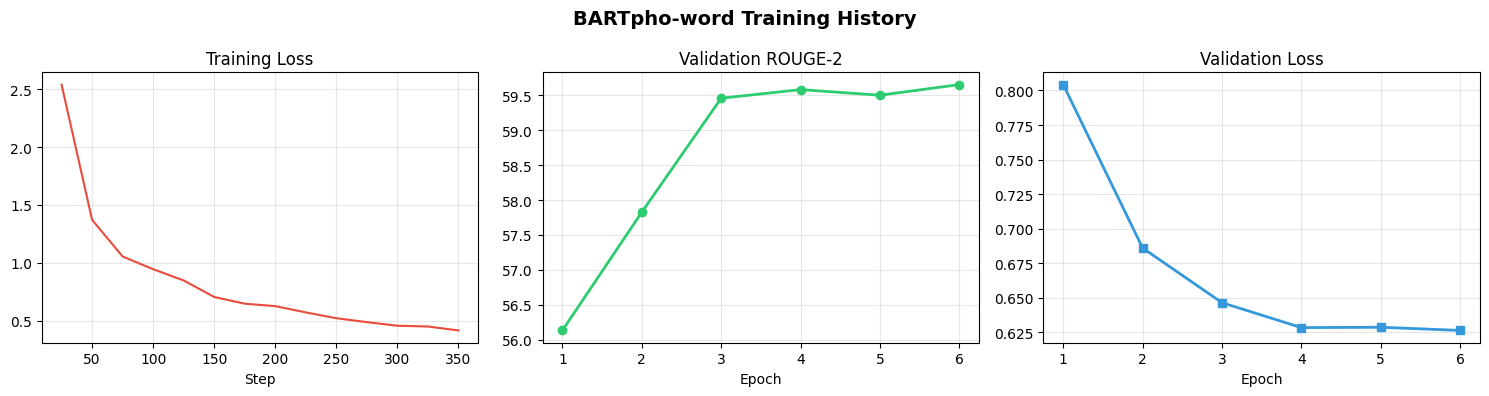

In [ ]:
# Plot training history
log_history = trainer.state.log_history
train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
eval_entries = [(e['epoch'], e.get('eval_rouge2',0), e.get('eval_loss',0))
                for e in log_history if 'eval_rouge2' in e]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('BARTpho-word Training History', fontsize=14, fontweight='bold')

if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, '#e74c3c', lw=1.5)
    axes[0].set_title('Training Loss'); axes[0].set_xlabel('Step'); axes[0].grid(alpha=0.3)

if eval_entries:
    epochs, r2s, eval_losses = zip(*eval_entries)
    axes[1].plot(epochs, r2s, '#2ecc71', marker='o', lw=2)
    axes[1].set_title('Validation ROUGE-2'); axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)
    axes[2].plot(epochs, eval_losses, '#3498db', marker='s', lw=2)
    axes[2].set_title('Validation Loss'); axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Đánh giá toàn diện trên tập Test

In [ ]:
from bert_score import score as bert_score_fn
import sacrebleu

best_model_path = f'{OUTPUT_DIR}/best_model'
eval_tokenizer  = AutoTokenizer.from_pretrained(best_model_path)
eval_model      = AutoModelForSeq2SeqLM.from_pretrained(best_model_path).to(device)
eval_model.eval()
print('✅ Best model loaded for evaluation!')


✅ Best model loaded for evaluation!


In [ ]:
def generate_summary_bartpho(text, model, tokenizer, src_word_count,
                              ratio_min=0.20, ratio_max=0.25,
                              num_beams=4, length_penalty=1.5):
    """
    Generate cho BARTpho - KHÔNG có prefix, forced_bos_token_id quan trọng.
    """
    min_tokens = max(10, int(src_word_count * ratio_min * 1.3))
    max_tokens = max(min_tokens + 10, int(src_word_count * ratio_max * 1.3))

    inputs = tokenizer(
        text,
        return_tensors='pt',
        max_length=MAX_INPUT_LEN,
        truncation=True
    ).to(device)

    # Một số tokenizer trả về token_type_ids, nhưng BARTpho/BART không dùng.
    # Nếu giữ lại, model.generate() sẽ báo lỗi:
    # ValueError: model_kwargs are not used by the model: ['token_type_ids']
    inputs.pop('token_type_ids', None)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            num_beams=num_beams,
            min_length=min_tokens,
            max_length=max_tokens,
            length_penalty=length_penalty,
            no_repeat_ngram_size=3,
            early_stopping=True,
            forced_bos_token_id=tokenizer.bos_token_id
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()


print('✅ Generate function ready!')


✅ Generate function ready!


In [ ]:
print(f'⏳ Generating {len(test_df)} summaries...')

predictions = []
references  = test_df['summary'].tolist()
sources     = test_df['original_text'].tolist()

for i, src in enumerate(sources):
    src_wc = word_count(src)
    pred   = generate_summary_bartpho(
        src, eval_model, eval_tokenizer, src_wc
    )
    predictions.append(pred)
    if (i+1) % 20 == 0:
        print(f'  [{i+1}/{len(test_df)}] done')

print(f'✅ Generation complete!')


⏳ Generating 126 summaries...
  [20/126] done
  [40/126] done
  [60/126] done
  [80/126] done
  [100/126] done
  [120/126] done
✅ Generation complete!


In [ ]:
# ============================================================
# TÍNH TẤT CẢ METRICS
# Number Accuracy:
# - Chỉ phạt số sinh ra trong prediction nhưng không có trong original_text.
# - Thiếu số trong original_text không bị phạt.
# ============================================================

print('📊 Tính ROUGE...')
rouge = evaluate.load('rouge')
rouge_results = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=False
)

print('📊 Tính BLEU...')
bleu_result = sacrebleu.corpus_bleu(predictions, [references])

print('📊 Tính BERTScore...')
P, R, F1 = bert_score_fn(
    predictions,
    references,
    lang='vi',
    model_type='xlm-roberta-base',
    verbose=False
)

print('📊 Tính Number Accuracy & Length Compliance...')
num_accuracy_scores = []
length_ok = []
hallucinated_counts = []

for pred, src in zip(predictions, sources):
    src_wc  = word_count(src)
    pred_wc = word_count(pred)
    ratio   = pred_wc / src_wc if src_wc > 0 else 0
    length_ok.append(0.20 <= ratio <= 0.25)

    acc, missing, hallucinated = number_accuracy_rate(src, pred)
    num_accuracy_scores.append(acc)
    hallucinated_counts.append(len(hallucinated))

print('\n' + '='*55)
print('      EVALUATION RESULTS — BARTpho-word')
print('='*55)
print(f"  ROUGE-1          : {rouge_results['rouge1']*100:.2f}")
print(f"  ROUGE-2          : {rouge_results['rouge2']*100:.2f}")
print(f"  ROUGE-L          : {rouge_results['rougeL']*100:.2f}")
print(f"  BLEU             : {bleu_result.score:.2f}")
print(f"  BERTScore F1     : {F1.mean().item()*100:.2f}")
print(f"  Number Accuracy  : {np.mean(num_accuracy_scores)*100:.2f}")
print(f"  Length Compliance: {np.mean(length_ok)*100:.2f}%")
print(f"  Avg wrong nums   : {np.mean(hallucinated_counts):.2f} per sample")
print('='*55)

eval_results = {
    'model':              'vinai/bartpho-word',
    'ROUGE-1':            round(rouge_results['rouge1']*100, 4),
    'ROUGE-2':            round(rouge_results['rouge2']*100, 4),
    'ROUGE-L':            round(rouge_results['rougeL']*100, 4),
    'BLEU':               round(bleu_result.score, 4),
    'BERTScore-F1':       round(F1.mean().item()*100, 4),
    'Number-Accuracy':    round(np.mean(num_accuracy_scores)*100, 4),
    'Length-Compliance':  round(np.mean(length_ok)*100, 4),
    'Avg-Wrong-Numbers':  round(np.mean(hallucinated_counts), 4)
}

with open(f'{OUTPUT_DIR}/eval_results.json', 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=2)
print(f'\n✅ Kết quả lưu tại {OUTPUT_DIR}/eval_results.json')



📊 Tính ROUGE...
📊 Tính BLEU...
📊 Tính BERTScore...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

📊 Tính Number Accuracy & Length Compliance...

      EVALUATION RESULTS — BARTpho-word
  ROUGE-1          : 77.63
  ROUGE-2          : 54.88
  ROUGE-L          : 55.82
  BLEU             : 44.35
  BERTScore F1     : 91.03
  Number Accuracy  : 98.77
  Length Compliance: 50.79%
  Avg wrong nums   : 0.10 per sample

✅ Kết quả lưu tại /content/drive/MyDrive/NLP_FINAL/BARTPHO_OUTPUT/eval_results.json


✅ Predictions saved!

⚠️  Mẫu có số liệu sai/ảo giác: 12 / 126

Ví dụ mẫu sinh số không có trong văn bản gốc:
  SRC             : Tiêu đề: Quốc hội chốt giảm thuế với xăng, dầu về 0 đến hết tháng 6
Nội dung: Sáng 12/4, Quốc hội đã thông qua Nghị quyết về thuế bảo vệ môi trường, g...
  PRED            : Sáng 12/4, Quốc hội đã thông qua Nghị quyết về thuế bảo vệ môi trường, giá trị gia tăng (VAT), thuế tiêu thụ đặc biệt với xăng, dầu và nhiên liệu bay....
  REF             : Sáng 12/4, Quốc hội đã thông qua Nghị quyết về thuế bảo vệ môi trường, giá trị gia tăng (VAT), thuế tiêu thụ đặc biệt với xăng, dầu và nhiên liệu bay....
  Number Accuracy : 0.857
  Wrong numbers   : {'30/4'}

  SRC             : Tiêu đề: Dragon Capital lên sàn trong tháng 1 với định giá hơn 2.000 tỷ đồng
Nội dung: Trong thông báo mới đây, Sở Giao dịch chứng khoán Hà Nội (HNX) ...
  PRED            : Dragon Capital lên sàn trong tháng 1 với định giá hơn 2.000 tỷ đồng. Trong thông báo mới đây, Sở Giao dịch chứng khoán

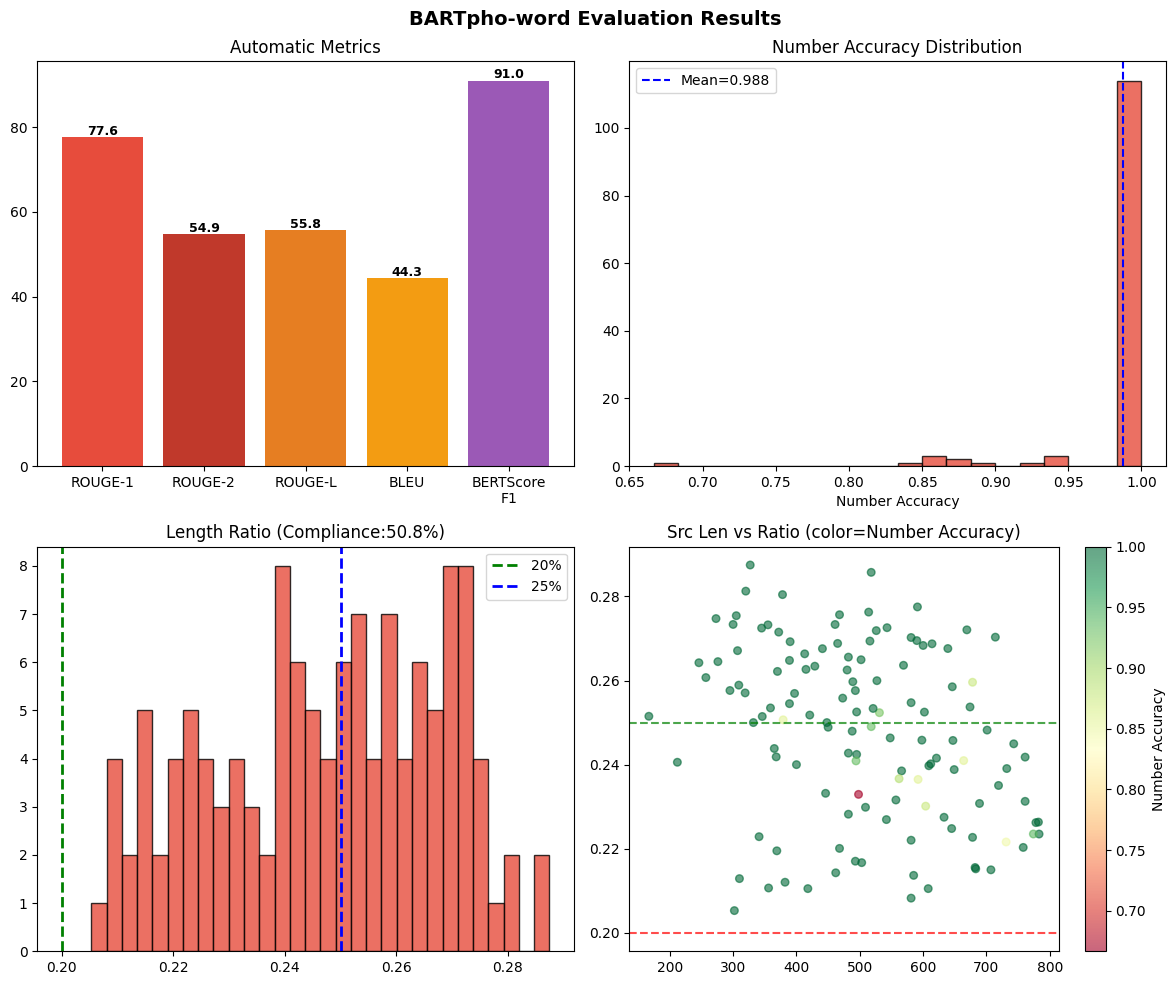

In [ ]:
# Lưu predictions
results_df = pd.DataFrame({
    'original_text':   sources,
    'reference':       references,
    'prediction':      predictions,
    'src_wc':          [word_count(s) for s in sources],
    'pred_wc':         [word_count(p) for p in predictions],
    'ref_wc':          [word_count(r) for r in references],
    'ratio':           [word_count(p)/word_count(s) if word_count(s)>0 else 0
                        for p,s in zip(predictions,sources)],
    'number_accuracy': num_accuracy_scores,
    'wrong_num_count': hallucinated_counts,
    'length_ok':       length_ok
})
results_df.to_csv(f'{OUTPUT_DIR}/test_predictions.csv', index=False, encoding='utf-8-sig')
print(f'✅ Predictions saved!')

# Phân tích lỗi: chỉ xem các mẫu có số liệu sai/ảo giác
bad_num_samples = results_df[results_df['number_accuracy'] < 1.0]
print(f'\n⚠️  Mẫu có số liệu sai/ảo giác: {len(bad_num_samples)} / {len(results_df)}')

if len(bad_num_samples) > 0:
    print('\nVí dụ mẫu sinh số không có trong văn bản gốc:')
    for _, row in bad_num_samples.head(3).iterrows():
        acc, missing, hallucinated = number_accuracy_rate(
            row['original_text'],
            row['prediction']
        )
        print(f'  SRC             : {row["original_text"][:150]}...')
        print(f'  PRED            : {row["prediction"][:150]}...')
        print(f'  REF             : {row["reference"][:150]}...')
        print(f'  Number Accuracy : {acc:.3f}')
        print(f'  Wrong numbers   : {hallucinated}\n')

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('BARTpho-word Evaluation Results', fontsize=14, fontweight='bold')

metric_names = ['ROUGE-1','ROUGE-2','ROUGE-L','BLEU','BERTScore\nF1']
metric_vals  = [
    rouge_results['rouge1']*100, rouge_results['rouge2']*100,
    rouge_results['rougeL']*100, bleu_result.score,
    F1.mean().item()*100
]
bars = axes[0,0].bar(metric_names, metric_vals,
                     color=['#e74c3c','#c0392b','#e67e22','#f39c12','#9b59b6'])
axes[0,0].set_title('Automatic Metrics')
for bar, val in zip(bars, metric_vals):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

axes[0,1].hist(num_accuracy_scores, bins=20, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0,1].axvline(np.mean(num_accuracy_scores), color='b', ls='--',
                  label=f'Mean={np.mean(num_accuracy_scores):.3f}')
axes[0,1].set_title('Number Accuracy Distribution')
axes[0,1].set_xlabel('Number Accuracy')
axes[0,1].legend()

axes[1,0].hist(results_df['ratio'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1,0].axvline(0.20, color='g', ls='--', lw=2, label='20%')
axes[1,0].axvline(0.25, color='b', ls='--', lw=2, label='25%')
axes[1,0].set_title(f'Length Ratio (Compliance:{np.mean(length_ok)*100:.1f}%)')
axes[1,0].legend()

sc = axes[1,1].scatter(results_df['src_wc'], results_df['ratio'],
                        c=results_df['number_accuracy'], cmap='RdYlGn', alpha=0.6, s=30)
axes[1,1].axhline(0.20, color='r', ls='--', alpha=0.7)
axes[1,1].axhline(0.25, color='g', ls='--', alpha=0.7)
axes[1,1].set_title('Src Len vs Ratio (color=Number Accuracy)')
plt.colorbar(sc, ax=axes[1,1], label='Number Accuracy')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eval_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()



## 7. So sánh ViT5 vs BARTpho

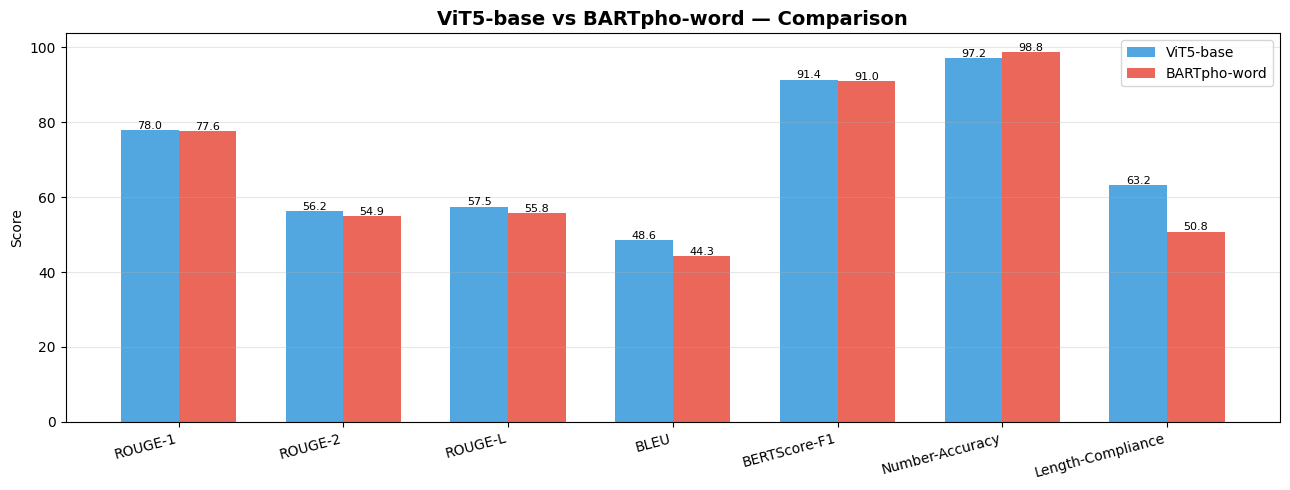


  Metric                       ViT5-base   BARTpho-word
  ROUGE-1                          77.98          77.63  ← ViT5
  ROUGE-2                          56.17          54.88  ← ViT5
  ROUGE-L                          57.46          55.82  ← ViT5
  BLEU                             48.63          44.35  ← ViT5
  BERTScore-F1                     91.37          91.03  ← ViT5
  Number-Accuracy                  97.16          98.77  BARTpho →
  Length-Compliance                63.16          50.79  ← ViT5


In [ ]:
VIT5_RESULT_PATH = '/content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/eval_results.json'

if os.path.exists(VIT5_RESULT_PATH):
    with open(VIT5_RESULT_PATH, 'r') as f:
        vit5_results = json.load(f)

    bartpho_results = eval_results
    metrics = ['ROUGE-1','ROUGE-2','ROUGE-L','BLEU','BERTScore-F1','Number-Accuracy','Length-Compliance']

    fig, ax = plt.subplots(figsize=(13, 5))
    x = np.arange(len(metrics))
    w = 0.35

    bars1 = ax.bar(x - w/2, [vit5_results.get(m,0) for m in metrics],
                   w, label='ViT5-base', color='#3498db', alpha=0.85)
    bars2 = ax.bar(x + w/2, [bartpho_results.get(m,0) for m in metrics],
                   w, label='BARTpho-word', color='#e74c3c', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=15, ha='right')
    ax.set_title('ViT5-base vs BARTpho-word — Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=8)

    plt.tight_layout()
    compare_path = '/content/drive/MyDrive/NLP_FINAL/model_comparison.png'
    plt.savefig(compare_path, dpi=150, bbox_inches='tight')
    plt.show()

    # In bảng so sánh
    print('\n' + '='*60)
    print(f'  {"Metric":<25} {"ViT5-base":>12} {"BARTpho-word":>14}')
    print('='*60)
    for m in metrics:
        v = vit5_results.get(m, 0)
        b = bartpho_results.get(m, 0)
        winner = '← ViT5' if v > b else 'BARTpho →'
        print(f'  {m:<25} {v:>12.2f} {b:>14.2f}  {winner}')
    print('='*60)
else:
    print('ℹ️ Chưa có kết quả ViT5. Chạy notebook ViT5 trước để so sánh!')



## 8. Inference & Demo

In [ ]:
def demo_summarize_bartpho(text, verbose=True):
    src_wc = word_count(text)
    summary = generate_summary_bartpho(
        text, eval_model, eval_tokenizer, src_wc
    )
    orig_nums = extract_numbers(text)
    summ_nums = extract_numbers(summary)
    missing   = orig_nums - summ_nums
    halluc    = summ_nums - orig_nums
    pred_wc   = word_count(summary)
    ratio     = pred_wc / src_wc

    if verbose:
        print('='*60)
        print('📄 VĂN BẢN GỐC:')
        print(text[:500] + ('...' if len(text) > 500 else ''))
        print('\n📝 BẢN TÓM TẮT (BARTpho):')
        print(summary)
        print('\n📊 THỐNG KÊ:')
        print(f'   Gốc: {src_wc} từ | Tóm tắt: {pred_wc} từ | Ratio: {ratio:.2%}',
              '✅' if 0.20 <= ratio <= 0.25 else '⚠️')
        print(f'   Số liệu thiếu : {missing if missing else "Không có ✅"}')
        if halluc:
            print(f'   Số ảo giác    : {halluc}')
        print('='*60)
    return summary

print('=== DEMO 3 MẪU TỪ TẬP TEST ===\n')
for i in range(min(3, len(test_df))):
    print(f'\n--- Mẫu {i+1} ---')
    _ = demo_summarize_bartpho(test_df['original_text'].iloc[i])


=== DEMO 3 MẪU TỪ TẬP TEST ===


--- Mẫu 1 ---
📄 VĂN BẢN GỐC:
Tiêu đề: Đà Nẵng đấu giá khu đất làm tổ hợp phục vụ Lễ hội pháo hoa quốc tế
Nội dung: UBND thành phố vừa ban hành quyết định tổ chức đấu giá quyền sử dụng đất dự án Tổ hợp công trình phục vụ Lễ hội pháo hoa quốc tế Đà Nẵng tại phường Ngũ Hành Sơn. Dự án có quy mô hơn 210.000 m2, trong đó phần diện tích đưa ra đấu giá là 48.000 m2. Khu vực này bao gồm các khu chức năng: A3, A6, A7, A8 và khu SK. Mức giá khởi điểm được xác định là 36,428 triệu đồng/m2, tiền đặt trước để tham gia đấu giá là hơn 350...

📝 BẢN TÓM TẮT (BARTpho):
UBND thành phố vừa ban hành quyết định tổ chức đấu giá quyền sử dụng đất dự án Tổ hợp công trình phục vụ Lễ hội pháo hoa quốc tế Đà Nẵng tại phường Ngũ Hành Sơn. Dự án có quy mô hơn 210.000 m2, trong đó phần diện tích đưa ra đấu giá là 48.000 m2. Khu vực này bao gồm các khu chức năng: A3, A6, A7, A8 và khu SK. Mức giá khởi điểm được xác định là 36,428 triệu đồng/m2. Mỗi kỳ lễ hội thường quy tụ từ 8 đến 10

## 9. Lưu model & Tổng kết

In [ ]:
config = {
    'model_name':      MODEL_NAME,
    'max_input_len':   MAX_INPUT_LEN,
    'max_target_len':  MAX_TARGET_LEN,
    'batch_size':      BATCH_SIZE,
    'grad_accum':      GRAD_ACCUM,
    'effective_batch': BATCH_SIZE * GRAD_ACCUM,
    'num_epochs':      NUM_EPOCHS,
    'learning_rate':   LEARNING_RATE,
    'warmup_steps':    WARMUP_STEPS,
    'weight_decay':    WEIGHT_DECAY,
    'num_beams':       NUM_BEAMS,
    'length_penalty':  LENGTH_PENALTY,
    'no_repeat_ngram': NO_REPEAT_NGRAM,
    'filter_long_samples': FILTER_LONG_SAMPLES,
    'filter_max_input_len': FILTER_MAX_INPUT_LEN,
    'filter_max_target_len': FILTER_MAX_TARGET_LEN,
    'filter_stats': FILTER_STATS,
    'seed':            SEED
}
with open(f'{OUTPUT_DIR}/training_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print('✅ Đã lưu tất cả output:')
print(f'   {OUTPUT_DIR}/')
print(f'   ├── best_model/          (model + tokenizer)')
print(f'   ├── checkpoints/')
print(f'   ├── eval_results.json')
print(f'   ├── test_predictions.csv')
print(f'   ├── training_config.json')
print(f'   ├── training_history.png')
print(f'   └── eval_visualizations.png')

print('\n📊 KẾT QUẢ CUỐI CÙNG (BARTpho):')
for k, v in eval_results.items():
    print(f'   {k:<25}: {v}')

# (Tuỳ chọn) Push lên HuggingFace
# from huggingface_hub import notebook_login
# notebook_login()
# eval_model.push_to_hub('your-username/bartpho-vietnamese-summarization')
# eval_tokenizer.push_to_hub('your-username/bartpho-vietnamese-summarization')



✅ Đã lưu tất cả output:
   /content/drive/MyDrive/NLP_FINAL/BARTPHO_OUTPUT/
   ├── best_model/          (model + tokenizer)
   ├── checkpoints/
   ├── eval_results.json
   ├── test_predictions.csv
   ├── training_config.json
   ├── training_history.png
   └── eval_visualizations.png

📊 KẾT QUẢ CUỐI CÙNG (BARTpho):
   model                    : vinai/bartpho-word
   ROUGE-1                  : 77.6329
   ROUGE-2                  : 54.8848
   ROUGE-L                  : 55.8242
   BLEU                     : 44.3462
   BERTScore-F1             : 91.0299
   Number-Accuracy          : 98.7701
   Length-Compliance        : 50.7937
   Avg-Wrong-Numbers        : 0.1032


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

best_model_path = "/content/drive/MyDrive/NLP_FINAL/BARTPHO_OUTPUT/best_model"

print("Đang load model từ:", best_model_path)

tokenizer = AutoTokenizer.from_pretrained(best_model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(best_model_path)

print("Load model thành công!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang load model từ: /content/drive/MyDrive/NLP_FINAL/BARTPHO_OUTPUT/best_model
Load model thành công!


In [ ]:
repo_id = "tranthaomy901/bartpho-vietnamese-summarization"

print("Đang push model lên Hugging Face Hub:", repo_id)

model.push_to_hub(repo_id)
tokenizer.push_to_hub(repo_id)

print("Push model thành công!")
print("Model repo:", f"https://huggingface.co/{repo_id}")

Đang push model lên Hugging Face Hub: tranthaomy901/bartpho-vietnamese-summarization


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...e2a12f3/model.safetensors:   0%|          |  262kB / 1.68GB            

README.md: 0.00B [00:00, ?B/s]

Push model thành công!
Model repo: https://huggingface.co/tranthaomy901/bartpho-vietnamese-summarization
